In [2]:
import pandas as pd
import numpy as np
#import glob

## Importacion data

### Drive

In [ ]:
!ls -R "/content/drive/MyDrive/Tesis-resultados"

ls: cannot access '/content/drive/MyDrive/Tesis-resultados': No such file or directory


In [3]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [4]:
import os
BASE = "/content/drive/MyDrive/Tesis-resultados"
print("Contenido BASE:", os.listdir(BASE))

Contenido BASE: ['Encuestas.pdf', 'outputs', 'QF1515-25-27.pdf', 'Inferencia Datos Categóricos con anotaciones 2025.pdf', 'Inferencia Datos Numéricos2 con anotaciones 2025.pdf', 'Codificación para digitar resultados.pdf', 'Partes importante jsjsjs.pdf', 'resultados.xlsx', 'EDA.ipynb']


In [5]:
import glob

hits = glob.glob("/content/drive/MyDrive/**/resultados.xlsx", recursive=True)
hits

['/content/drive/MyDrive/Tesis-resultados (1)/resultados.xlsx',
 '/content/drive/MyDrive/Tesis-resultados/resultados.xlsx']

In [ ]:
paths = glob.glob("/content/drive/MyDrive/**/Tesis-resultados", recursive=True)
paths[:10]

['/content/drive/MyDrive/Tesis-resultados']

In [6]:
xls = glob.glob(f"{BASE}/*.xlsx")
xls
resultados_total = pd.read_excel(xls[0])
resultados_total['analfabeta'] = np.where(resultados_total['Sabe leer'] + resultados_total['Sabe escribir'] == 2, 0,1)
resultados_total.head()

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,Lugar,analfabeta
0,1,30,1,1,4,1,0,2,0,1,0,2,1.0,NaN,0,0,San Yuyo,1
1,2,38,2,6,4,1,0,0,0,1,1,1,0.0,NaN,1,1,San Carlos Alzatate,0
2,3,38,2,1,4,1,0,1,0,0,1,1,1.0,NaN,0,0,San Carlos Alzatate,1
3,4,30,2,1,1,1,1,0,0,0,0,2,0.0,NaN,0,0,Monjas,1
4,5,24,2,2,4,2,0,1,0,1,1,0,2.0,NaN,1,1,San Yuyo,0


In [7]:
resultados_total.shape

(196, 18)

In [8]:
resultados_total.columns

Index(['ID', 'EDAD', 'SEXO', 'ESCOLARIDAD', 'ETNIA', 'P1', 'P2', 'P3', 'P4',
       'P5', 'P6', 'P7', 'P8', 'PUNTUACIÓN', 'Sabe leer', 'Sabe escribir',
       'Lugar', 'analfabeta'],
      dtype='object')

In [9]:
import os
BASE = "/content/drive/MyDrive/Tesis-resultados"
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

### Local

In [47]:
resultados_Pre = pd.read_excel("C:\\Users\\rhernandez\\OneDrive - Generando Soluciones Anlalíticas S.A\\Documents\\EDA\\resultados.xlsx", sheet_name="Pre")
resultados_Pro = pd.read_excel("C:\\Users\\rhernandez\\OneDrive - Generando Soluciones Anlalíticas S.A\\Documents\\EDA\\resultados.xlsx", sheet_name="Post")
resultados_Pre['estado'] = 'pre'
resultados_Pro['estado'] = 'post'
resultados_total = pd.concat([resultados_Pre, resultados_Pro], ignore_index=True)
resultados_total['analfabeta'] = np.where(resultados_total['Sabe leer'] + resultados_total['Sabe escribir'] == 2, 0,1)
resultados_total.head()

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,Lugar,estado,analfabeta
0,1,30,1,1,4,1,0,2,0,1,0,2,1.0,NaN,0,0,San Yuyo,pre,1
1,2,38,2,6,4,1,0,0,0,1,1,1,0.0,NaN,1,1,San Carlos Alzatate,pre,0
2,3,38,2,1,4,1,0,1,0,0,1,1,1.0,NaN,0,0,San Carlos Alzatate,pre,1
3,4,30,2,1,1,1,1,0,0,0,0,2,0.0,NaN,0,0,Monjas,pre,1
4,5,24,2,2,4,2,0,1,0,1,1,0,2.0,NaN,1,1,San Yuyo,pre,0


## Graficas

/tmp/ipython-input-491/3348382662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=resultados_total, x='ETNIA', palette='pastel')


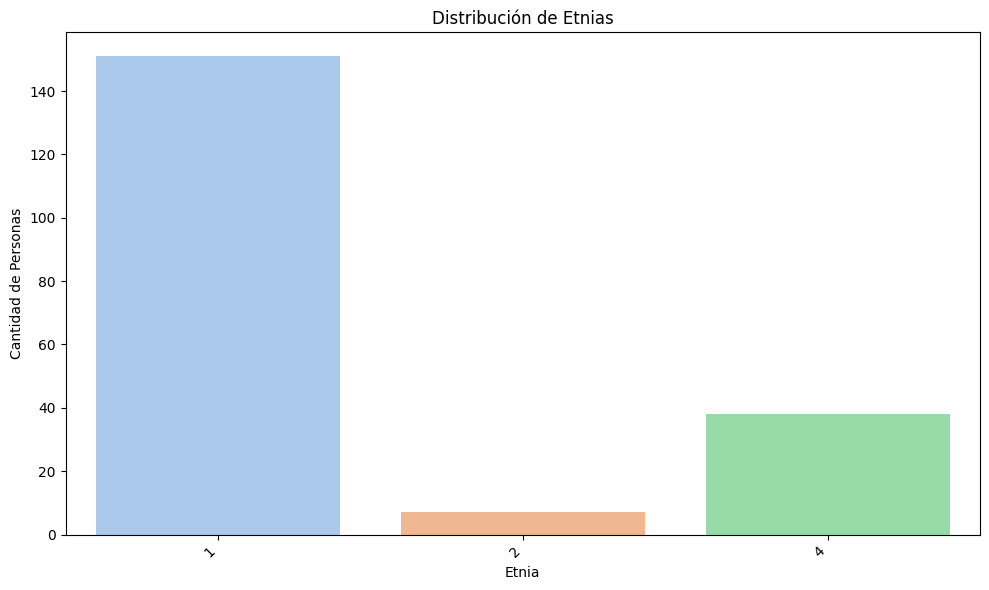

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(10, 6))
sns.countplot(data=resultados_total, x='ETNIA', palette='pastel')
plt.title('Distribución de Etnias')
plt.xlabel('Etnia')
plt.ylabel('Cantidad de Personas')

plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT, "etnia_distribution_count.png"), dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipython-input-491/2207960953.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=resultados_total, x='Rango_Edad', palette='pastel', order=labels)


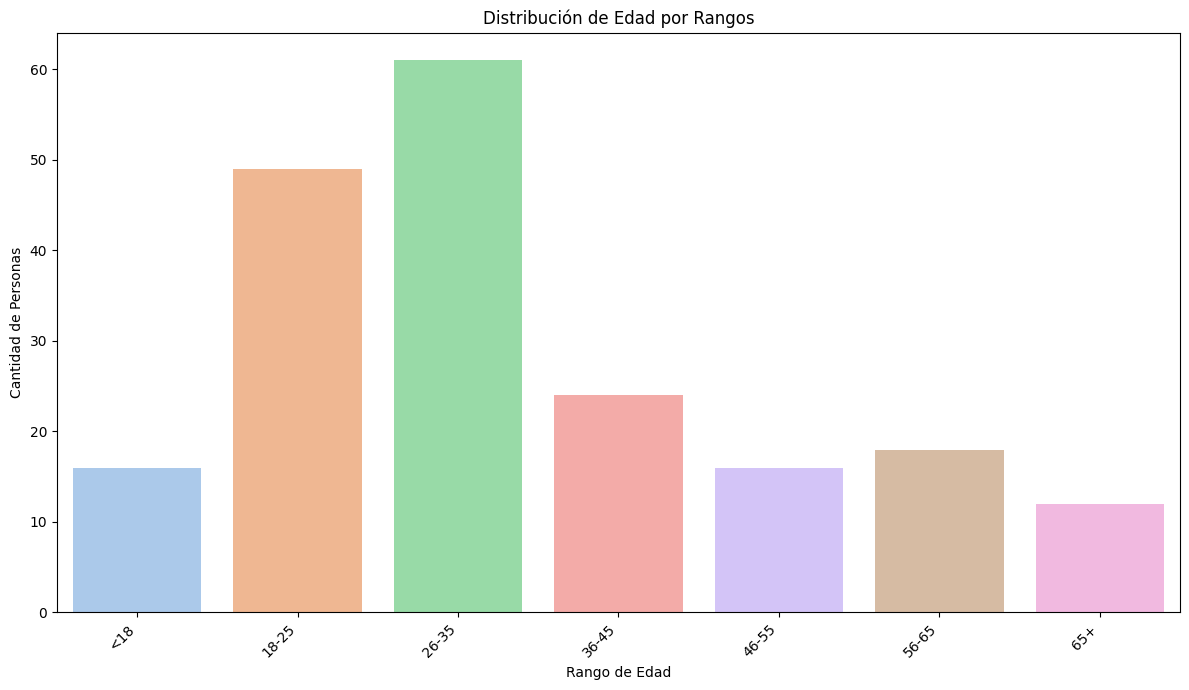

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the age bins based on user request
bins = [0, 17, 25, 35, 45, 55, 65, 100] # Adjust upper bound as needed for your data
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

# Create a new column with age ranges for easier plotting
resultados_total['Rango_Edad'] = pd.cut(resultados_total['EDAD'], bins=bins, labels=labels, right=False)
plt.figure(figsize=(12, 7))
sns.countplot(data=resultados_total, x='Rango_Edad', palette='pastel', order=labels)
plt.title('Distribución de Edad por Rangos')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT, "edad_histograma_rangos.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
resultados_total.shape

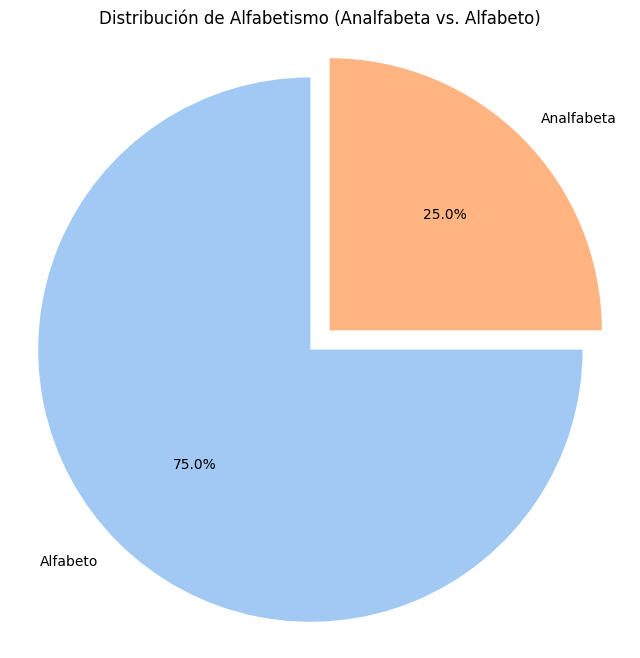

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

literacy_counts = resultados_total['analfabeta'].value_counts()

labels = ['Alfabeto' if x == 0 else 'Analfabeta' for x in literacy_counts.index]
colors = sns.color_palette('pastel')[0:len(literacy_counts)]

plt.figure(figsize=(8, 8))
plt.pie(literacy_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=[0.05]*len(literacy_counts))
plt.title('Distribución de Alfabetismo (Analfabeta vs. Alfabeto)')
plt.axis('equal')
plt.savefig(os.path.join(OUT, "analfabetismo_pie_chart.png"), dpi=300, bbox_inches="tight")
plt.show()

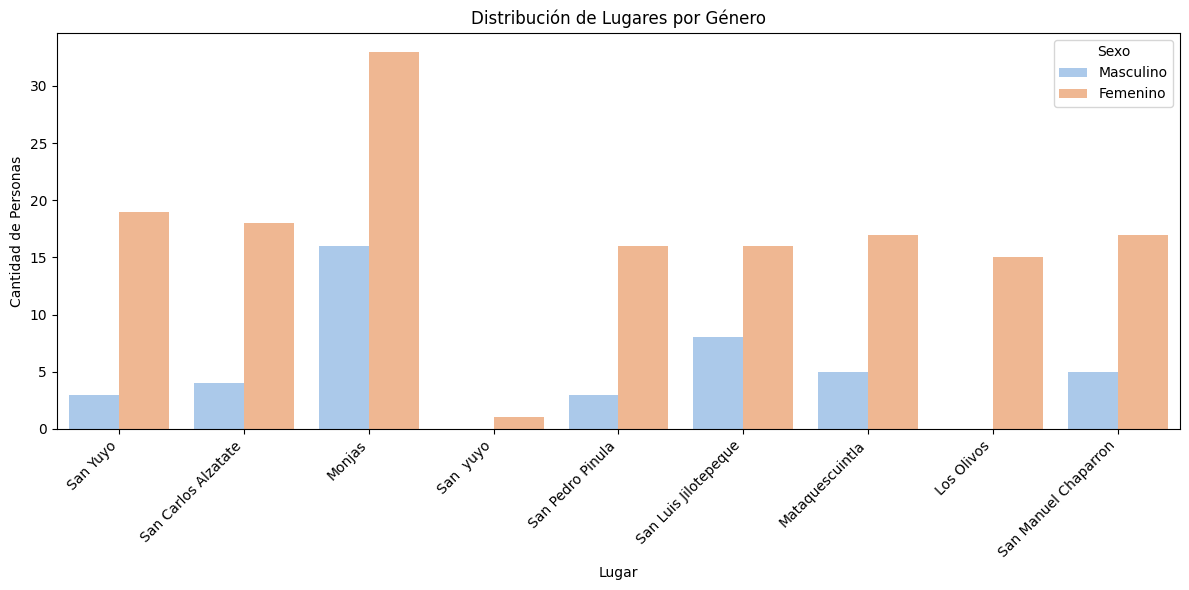

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=resultados_total, x='Lugar', hue='SEXO', palette='pastel')
plt.title('Distribución de Lugares por Género')
plt.xlabel('Lugar')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sexo', labels=['Masculino', 'Femenino'])
plt.tight_layout()
plt.savefig(os.path.join(OUT, "genero_lugar_count.png"), dpi=300, bbox_inches="tight")
plt.show()

## Pre y post

In [48]:
resultados_total['resultado_final']= resultados_total[['P1','P2','P3','P4','P5','P6','P7','P8']].sum(axis=1)

In [24]:
resultados_total.head()

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,Lugar,estado,analfabeta,resultado_final
0,1,30,1,1,4,1,0,2,0,1,0,2,1.0,NaN,0,0,San Yuyo,pre,1,7.0
1,2,38,2,6,4,1,0,0,0,1,1,1,0.0,NaN,1,1,San Carlos Alzatate,pre,0,4.0
2,3,38,2,1,4,1,0,1,0,0,1,1,1.0,NaN,0,0,San Carlos Alzatate,pre,1,5.0
3,4,30,2,1,1,1,1,0,0,0,0,2,0.0,NaN,0,0,Monjas,pre,1,4.0
4,5,24,2,2,4,2,0,1,0,1,1,0,2.0,NaN,1,1,San Yuyo,pre,0,7.0


In [38]:
resultados_total['ETNIA'].unique()

array([4, 1, 2])

In [ ]:
resultados_total[resultados_total['ID'] == 1]
#

,ID,EDAD,SEXO,ESCOLARIDAD,ETNIA,P1,P2,P3,P4,P5,P6,P7,P8,PUNTUACIÓN,Sabe leer,Sabe escribir,Lugar,estado,analfabeta,resultado_final
0,1,30,1,1,4,1,0,2,0,1,0,2,1.0,NaN,0,0,San Yuyo,pre,1,7.0
196,1,30,1,1,4,1,0,2,1,0,0,0,1.0,NaN,0,0,San Yuyo,post,1,5.0


In [ ]:
# -Distribución por distrito/servicio de salud.
# -Análisis de conocimiento
# -Gráficas comparativas PRE vs POST por preguntas clave:
#      P4 (prevención de diarrea)
#      P6 (uso de antibióticos sin receta)P7 (antibiótico en resfriado)
#      P8 (uso de ibuprofeno/aspirina en dengue)
# -Gráfica de diferencia porcentual de respuestas correctas PRE vs POST.
# -Tabla comparativa general PRE vs POST por distrito.
# -Consolidado general de los servicios de salud.

# Pertinencia cultural
# gráfica Comparación PRE vs POST por grupo étnico.
# Tabla cruzada Etnia × Respuesta correcta (preguntas clave).
# tabla/ gráficaValidación del programa educativo por grupo étnico.
# tabla Validación del programa

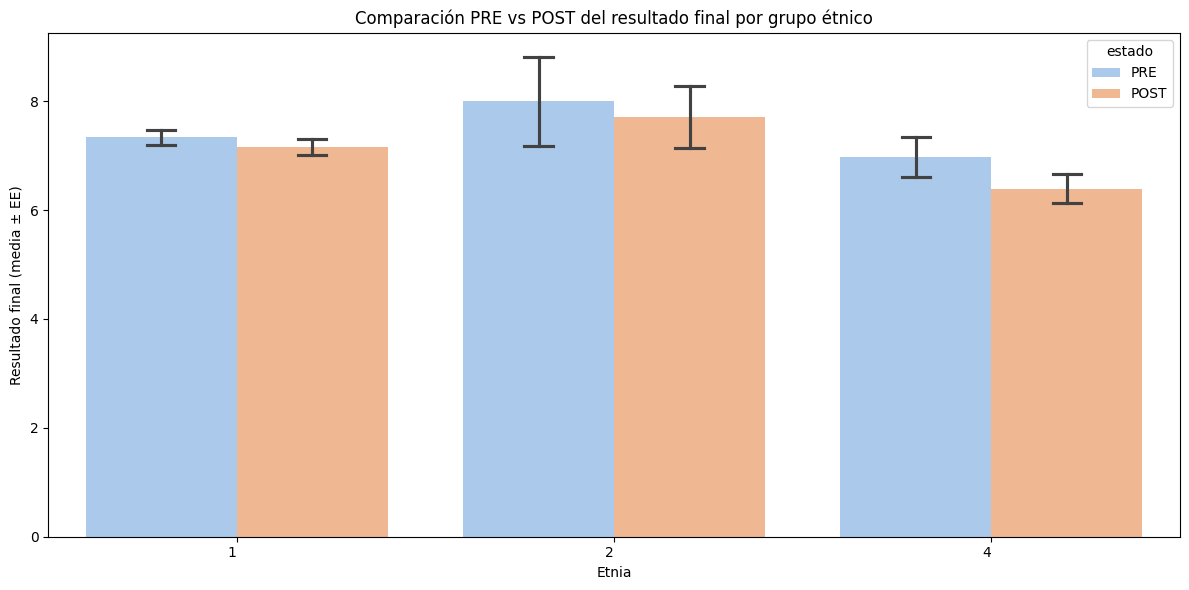

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

df = resultados_total.copy()
df["estado"] = df["estado"].astype(str).str.strip().str.upper()
df["resultado_final"] = pd.to_numeric(df["resultado_final"], errors="coerce")
df = df[df["estado"].isin(["PRE", "POST"])]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="ETNIA",
    y="resultado_final",
    hue="estado",
    palette="pastel",
    order=sorted(df["ETNIA"].dropna().unique()),
    hue_order=["PRE", "POST"],
    errorbar="se",     # si te da error, mira el bloque de abajo
    capsize=0.15
)

plt.title("Comparación PRE vs POST del resultado final por grupo étnico")
plt.xlabel("Etnia")
plt.ylabel("Resultado final (media ± EE)")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "resultado_final_pre_vs_post_por_etnia.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# EE = Error Estándar (standard error).
# En la gráfica “media ± EE”, las barras muestran el promedio de resultado_final y las “patitas” (error bars) muestran qué tan precisa es esa media.
# EE = desviación estándar / √n
# Si EE es pequeño, la media está estimada con más precisión.
# Si EE es grande, hay más variabilidad y/o pocos datos.
# Ojo: EE no es lo mismo que desviación estándar (DE).
# DE = qué tanto varían los datos individuales.
# EE = qué tanto puede variar la media si repitieras el muestreo.
# Si preferís que las barras muestren DE (más intuitivo a veces), te cambio el código a errorbar="sd" (o equivalente).

In [39]:
resultados_total['P7'] = np.where((resultados_total['P7'] == 2) | (resultados_total['P7'] == 0), 0, 1)

C:\Users\rhernandez\AppData\Local\Temp\ipykernel_14548\91782522.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


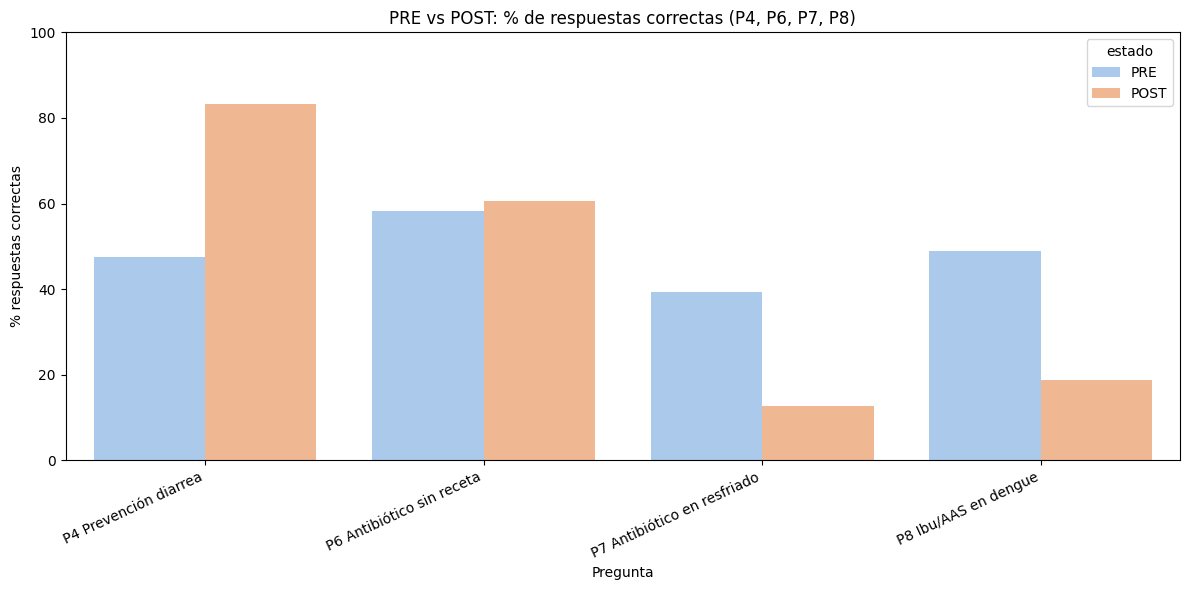

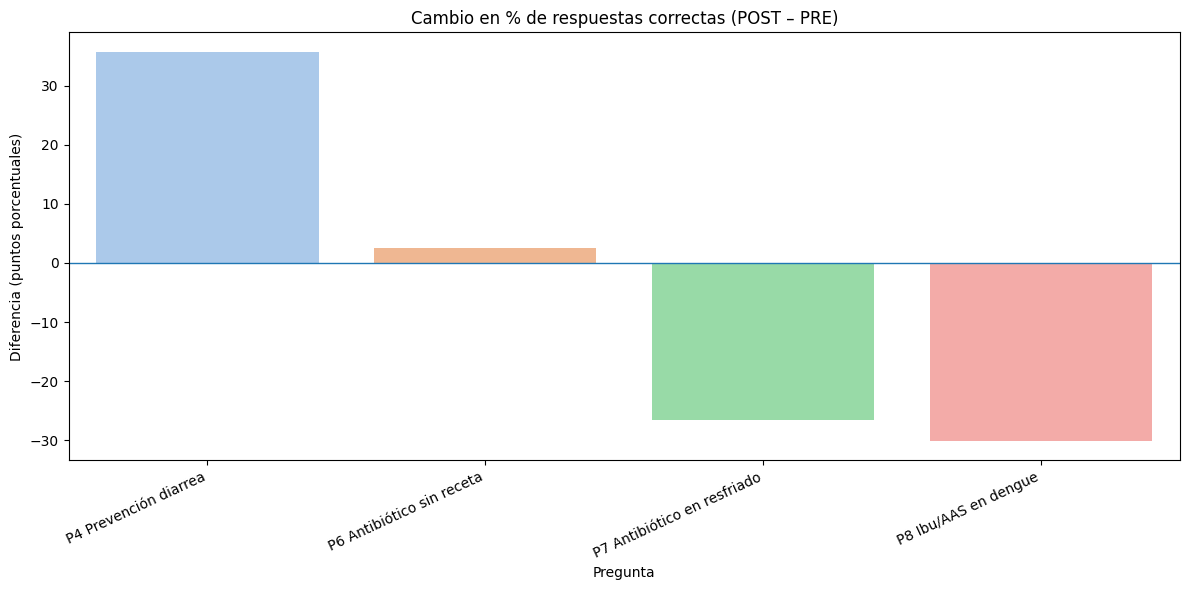

In [52]:
# --- Config ---
questions = ["P4", "P6", "P7", "P8"]
q_labels = {
    "P4": "P4 Prevención diarrea",
    "P6": "P6 Antibiótico sin receta",
    "P7": "P7 Antibiótico en resfriado",
    "P8": "P8 Ibu/AAS en dengue"
}

df = resultados_total.copy()
df["estado"] = df["estado"].astype(str).str.strip().str.upper()
df = df[df["estado"].isin(["PRE", "POST"])]

# Asegurar numérico
for q in questions:
    df[q] = pd.to_numeric(df[q], errors="coerce")

# --- Definir "correcto" por pregunta ---
# Opción A (por defecto): correcto = valor máximo observado (útil si 0/1/2 es puntuación)
correct_key = df[questions].max().to_dict()

# --- Long format + % correcto ---
long = df.melt(id_vars=["estado"], value_vars=questions, var_name="pregunta", value_name="respuesta")
long["key"] = long["pregunta"].map(correct_key)
long["correcta"] = (long["respuesta"] == long["key"]).astype(float)

grp = (long.groupby(["pregunta", "estado"])["correcta"]
       .mean()
       .reset_index())
grp["porc_correctas"] = grp["correcta"] * 100
grp["pregunta_lbl"] = grp["pregunta"].map(q_labels)

order_lbl = [q_labels[q] for q in questions]

# =========================
# 1) PRE vs POST por pregunta
# =========================
plt.figure(figsize=(12, 6))
sns.barplot(
    data=grp,
    x="pregunta_lbl",
    y="porc_correctas",
    hue="estado",
    palette="pastel",
    order=order_lbl,
    hue_order=["PRE", "POST"],
    errorbar=None
)

plt.title("PRE vs POST: % de respuestas correctas (P4, P6, P7, P8)")
plt.xlabel("Pregunta")
plt.ylabel("% respuestas correctas")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "pre_vs_post_porcentaje_correctas_P4_P6_P7_P8.png"), dpi=300, bbox_inches="tight")
#plt.show()

# =========================
# 2) Diferencia porcentual POST - PRE (puntos porcentuales)
# =========================
wide = grp.pivot(index="pregunta", columns="estado", values="porc_correctas")
wide["diff_pp"] = wide.get("POST", np.nan) - wide.get("PRE", np.nan)

diff_df = wide.reset_index()
diff_df["pregunta_lbl"] = diff_df["pregunta"].map(q_labels)
diff_df = diff_df.sort_values("diff_pp", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=diff_df,
    x="pregunta_lbl",
    y="diff_pp",
    palette="pastel",
    errorbar=None
)
plt.axhline(0, linewidth=1)

plt.title("Cambio en % de respuestas correctas (POST – PRE)")
plt.xlabel("Pregunta")
plt.ylabel("Diferencia (puntos porcentuales)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "diferencia_porcentual_correctas_POST_menos_PRE_P4_P6_P7_P8.png"), dpi=300, bbox_inches="tight")
plt.show()

In [51]:
import pandas as pd
import numpy as np
import os
import re

BASE = r"C:\Users\rhernandez\OneDrive - Generando Soluciones Anlalíticas S.A\Documents\EDA"
OUT = os.path.join(BASE, "outputs")

# crea la carpeta outputs si no existe
os.makedirs(OUT, exist_ok=True)

print("BASE:", BASE)
print("OUT :", OUT)

# ==== Mapeos según tu codificación ====
MAP = {
    "P1": {1: "Centro de salud", 2: "Compra medicamento", 3: "Vecino/familiar", 4: "Otra"},
    "P2": {1: "Si", 0: "No"},
    "P3": {1: "Si", 0: "No", 2: "A veces"},
    "P4": {1: "Si", 0: "No"},
    "P5": {1: "Si", 0: "No"},
    "P6": {1: "Si", 0: "No"},
    "P7": {0: "No", 1: "Si", 2: "No sabe"},          # orden como tu plantilla
    "P8": {1: "Si", 0: "No", 2: "No estoy seguro"},    # orden como tu plantilla
}

ORDER = {
    "P1": ["Centro de salud", "Compra medicamento", "Vecino/familiar"],  # si querés incluir "Otra", agrégalo aquí
    "P2": ["Si", "No"],
    "P3": ["Si", "No", "A veces"],
    "P4": ["Si", "No"],
    "P5": ["Si", "No"],
    "P6": ["Si", "No"],
    "P7": ["No", "Si", "No sabe"],
    "P8": ["Si", "No", "No estoy seguro"],
}

QUESTIONS = ["P1","P2","P3","P4","P5","P6","P7","P8"]

# ==== Indicadores (respuesta correcta asumida) ====
# Ajustá si tus “correctas” son distintas:
CORRECT = {
    "P4": 1,  # prevención diarrea: Sí
    "P6": 0,  # antibiótico sin receta: No
    "P7": 0,  # antibiótico en resfriado: No
    "P8": 0,  # ibuprofeno/aspirina en dengue: No
}

def clean_sheet_name(name: str) -> str:
    name = re.sub(r"[\[\]\:\*\?\/\\]", " ", str(name))
    name = re.sub(r"\s+", " ", name).strip()
    return name[:31] if name else "Lugar"

def tabla_distribucion(df_sub: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for q in QUESTIONS:
        if q not in df_sub.columns:
            continue
        s = pd.to_numeric(df_sub[q], errors="coerce")
        s = s.dropna()

        # total respuestas válidas por pregunta (para %)
        n = len(s)
        # contar por código y mapear a categoría
        vc = s.value_counts(dropna=False).to_dict()

        # construir filas respetando el orden deseado
        categorias = ORDER.get(q, list(MAP[q].values()))
        for cat in categorias:
            # buscar qué código(s) corresponden a esa categoría
            codigos = [k for k,v in MAP[q].items() if v == cat]
            freq = int(sum(vc.get(c, 0) for c in codigos))
            pct = (freq / n * 100) if n > 0 else 0.0

            rows.append({
                "Pregunta": q,
                "Categoria": cat,
                "Frecuencia": freq,
                "Porcentaje (%)": round(pct, 2)
            })
    return pd.DataFrame(rows)

def tabla_indicadores(df_lugar: pd.DataFrame) -> pd.DataFrame:
    out = []
    for q, correct_code in CORRECT.items():
        if q not in df_lugar.columns:
            continue

        def pct_correct(estado):
            sub = df_lugar[df_lugar["estado"] == estado]
            s = pd.to_numeric(sub[q], errors="coerce").dropna()
            if len(s) == 0:
                return np.nan
            return float((s == correct_code).mean() * 100)

        pre = pct_correct("PRE")
        post = pct_correct("POST")
        diff = (post - pre) if (pd.notna(pre) and pd.notna(post)) else np.nan

        out.append({
            "Indicador": q,
            "PRE (%)": round(pre, 2) if pd.notna(pre) else np.nan,
            "POST (%)": round(post, 2) if pd.notna(post) else np.nan,
            "Diferencia (%)": round(diff, 2) if pd.notna(diff) else np.nan,  # puntos porcentuales
        })
    return pd.DataFrame(out)

# ==== Preparar df ====
df = resultados_total.copy()
df["estado"] = df["estado"].astype(str).str.strip().str.upper()
df = df[df["estado"].isin(["PRE","POST"])]

# asegurar numéricas en preguntas
for q in QUESTIONS:
    if q in df.columns:
        df[q] = pd.to_numeric(df[q], errors="coerce")

# ==== Exportar Excel por Lugar ====
out_path = os.path.join(OUT, "tablas_por_lugar.xlsx")

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    for lugar in sorted(df["Lugar"].dropna().unique()):
        sheet = clean_sheet_name(lugar)
        df_l = df[df["Lugar"] == lugar]

        # PRE
        pre_tbl = tabla_distribucion(df_l[df_l["estado"] == "PRE"])
        # POST
        post_tbl = tabla_distribucion(df_l[df_l["estado"] == "POST"])
        # Indicadores
        ind_tbl = tabla_indicadores(df_l)

        r = 0
        # Encabezado PRE
        pd.DataFrame({"Distribución": [f"Lugar: {lugar} - PRE"]}).to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += 2
        pre_tbl.to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += len(pre_tbl) + 3

        # Encabezado POST
        pd.DataFrame({"Distribución": [f"Lugar: {lugar} - POST"]}).to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += 2
        post_tbl.to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += len(post_tbl) + 4

        # Indicadores PRE vs POST
        pd.DataFrame({"": ["Indicador"]}).to_excel(writer, sheet_name=sheet, index=False, startrow=r)
        r += 1
        ind_tbl.to_excel(writer, sheet_name=sheet, index=False, startrow=r)

print("Guardado:", out_path)

BASE: C:\Users\rhernandez\OneDrive - Generando Soluciones Anlalíticas S.A\Documents\EDA
OUT : C:\Users\rhernandez\OneDrive - Generando Soluciones Anlalíticas S.A\Documents\EDA\outputs
Guardado: C:\Users\rhernandez\OneDrive - Generando Soluciones Anlalíticas S.A\Documents\EDA\outputs\tablas_por_lugar.xlsx
